## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [3]:
# If you didn't download it yet, please get the relevant file now!
#!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

In [4]:
import pandas as pd
import numpy.random as npr

file_name="./data/data_000637.txt"
data = pd.read_csv(file_name)
df = pd.DataFrame(data)
df.head(10)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
0,1,0,123,3869200167,2374,26
1,1,0,124,3869200167,2374,27
2,1,0,63,3869200167,2553,28
3,1,0,64,3869200167,2558,19
4,1,0,64,3869200167,2760,25
5,1,0,63,3869200167,2762,4
6,1,0,61,3869200167,2772,14
7,1,0,139,3869200167,2776,0
8,1,0,62,3869200167,2774,21
9,1,0,60,3869200167,2788,7


2\. Find out the number of BX in a ORBIT (the value 'x').

In [5]:
orbit_group = df.groupby('ORBIT_CNT')['BX_COUNTER'].count()
orbit_group_unique = df.groupby('ORBIT_CNT')['BX_COUNTER'].nunique()
print(orbit_group.head(10), orbit_group_unique.head(10))

ORBIT_CNT
3869200167     43
3869200168     85
3869200169    127
3869200170     98
3869200171    109
3869200172     89
3869200173     88
3869200174    128
3869200175    128
3869200176     51
Name: BX_COUNTER, dtype: int64 ORBIT_CNT
3869200167     34
3869200168     68
3869200169     95
3869200170     80
3869200171     83
3869200172     78
3869200173     79
3869200174    101
3869200175     92
3869200176     41
Name: BX_COUNTER, dtype: int64


3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

In [6]:
orbit_max = df['ORBIT_CNT'].max()
orbit_min = df['ORBIT_CNT'].min()
bx_max = df[df['ORBIT_CNT'] == orbit_max]['BX_COUNTER'].max()
bx_min = df[df['ORBIT_CNT'] == orbit_min]['BX_COUNTER'].min()
tdc_max = df[df['ORBIT_CNT'] == orbit_max][df['BX_COUNTER'] == bx_max]['TDC_MEAS'].max()
tdc_min = df[df['ORBIT_CNT'] == orbit_min][df['BX_COUNTER'] == bx_min]['TDC_MEAS'].min()
orbit_to_bx = df['BX_COUNTER'].max() + 1
print("Orbit to bx:", orbit_to_bx)

time_acquisition = ((orbit_max * orbit_to_bx + bx_max + tdc_max / 30) - (orbit_min * orbit_to_bx + bx_min + tdc_min / 30)) * 25
print("Acquisition time: ", time_acquisition, " ns")


Orbit to bx: 3564
Acquisition time:  980416253.3203125  ns


/tmp/ipykernel_10476/839669229.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tdc_max = df[df['ORBIT_CNT'] == orbit_max][df['BX_COUNTER'] == bx_max]['TDC_MEAS'].max()
/tmp/ipykernel_10476/839669229.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  tdc_min = df[df['ORBIT_CNT'] == orbit_min][df['BX_COUNTER'] == bx_min]['TDC_MEAS'].min()


4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

In [7]:
timing = ((df['ORBIT_CNT'] - orbit_min) * orbit_to_bx + (df['BX_COUNTER'] - bx_min) + (df['TDC_MEAS'] - tdc_min) / 30) * 25
df["TIMING"] = timing
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,TIMING
0,1,0,123,3869200167,2374,26,0.000000e+00
1,1,0,124,3869200167,2374,27,8.333333e-01
2,1,0,63,3869200167,2553,28,4.476667e+03
3,1,0,64,3869200167,2558,19,4.594167e+03
4,1,0,64,3869200167,2760,25,9.649167e+03
...,...,...,...,...,...,...,...
1310715,1,0,62,3869211171,762,14,9.804161e+08
1310716,1,1,4,3869211171,763,11,9.804161e+08
1310717,1,0,64,3869211171,764,0,9.804161e+08
1310718,1,0,139,3869211171,769,0,9.804163e+08


5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

In [8]:
df['HEAD'] = npr.choice(2, size=len(df))
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,TIMING
0,0,0,123,3869200167,2374,26,0.000000e+00
1,1,0,124,3869200167,2374,27,8.333333e-01
2,1,0,63,3869200167,2553,28,4.476667e+03
3,1,0,64,3869200167,2558,19,4.594167e+03
4,1,0,64,3869200167,2760,25,9.649167e+03
...,...,...,...,...,...,...,...
1310715,1,0,62,3869211171,762,14,9.804161e+08
1310716,1,1,4,3869211171,763,11,9.804161e+08
1310717,0,0,64,3869211171,764,0,9.804161e+08
1310718,1,0,139,3869211171,769,0,9.804163e+08


6\. Create a new DataFrame that contains only the rows with HEAD=1.

In [9]:
df_head1 = df[df['HEAD'] == 1]
df_head1

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,TIMING
1,1,0,124,3869200167,2374,27,8.333333e-01
2,1,0,63,3869200167,2553,28,4.476667e+03
3,1,0,64,3869200167,2558,19,4.594167e+03
4,1,0,64,3869200167,2760,25,9.649167e+03
7,1,0,139,3869200167,2776,0,1.002833e+04
...,...,...,...,...,...,...,...
1310713,1,0,64,3869211171,758,18,9.804160e+08
1310714,1,0,60,3869211171,762,2,9.804161e+08
1310715,1,0,62,3869211171,762,14,9.804161e+08
1310716,1,1,4,3869211171,763,11,9.804161e+08


7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

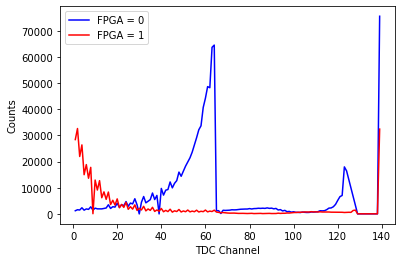

In [17]:
import matplotlib.pyplot as plt

fpga0 = df[df['FPGA'] == 0]
fpga1 = df[df['FPGA'] == 1]
count0 = fpga0.groupby('TDC_CHANNEL')['HEAD'].count()
count1 = fpga1.groupby('TDC_CHANNEL')['HEAD'].count()

plt.plot(count0.index, count0, label='FPGA = 0', c='blue')
plt.plot(count1.index, count1, label='FPGA = 1', c='red')
plt.xlabel('TDC Channel')
plt.ylabel('Counts')
plt.legend()
plt.show()

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

In [11]:
tdc_channels = df.groupby('TDC_CHANNEL')['HEAD'].count().sort_values(ascending=False)
tdc_channels.head(3)

TDC_CHANNEL
139    108059
64      66020
63      64642
Name: HEAD, dtype: int64

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [12]:
unique_orbits = df['ORBIT_CNT'].nunique()
print("Unique orbits: ", unique_orbits)
unique_orbits_139 = df[df['TDC_CHANNEL'] == 139]['ORBIT_CNT'].nunique()
print("Unique orbits from TDC_CHANNEL = 139: ",unique_orbits_139)
#df[df['TDC_CHANNEL'] == 139]

Unique orbits:  11001
Unique orbits from TDC_CHANNEL = 139:  10976
